In [15]:
# Data Analysis

import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing

from sklearn.preprocessing import LabelEncoder

# Train Test Split

from sklearn.model_selection import train_test_split

# Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [19]:
# Load Dataset

df = pd.read_csv("/content/loan prediction.csv")

In [20]:
# First 5 Rows

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [21]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [22]:
# Rows and Columns

print(df.shape)

(614, 13)


In [23]:
# Statistics

df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [24]:
# Missing Values

df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [30]:
# Categorical Columns
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Married'] = df['Married'].fillna(df['Married'].mode()[0])

df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [36]:
# Numerical Column
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())

In [37]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


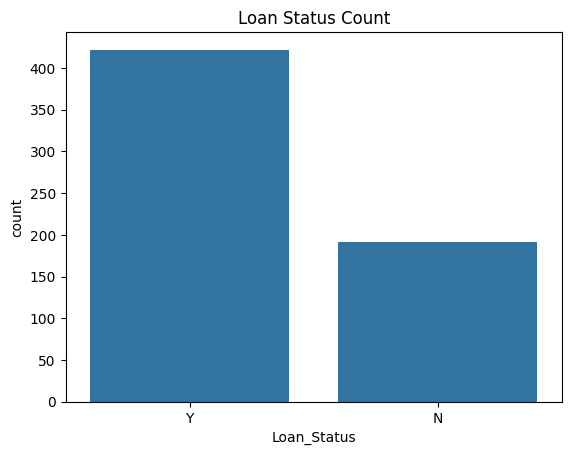

In [38]:
# Exploratory Data Analysis (EDA)

# 1 Loan Status Count
sns.countplot(x='Loan_Status', data=df)

plt.title("Loan Status Count")

plt.show()

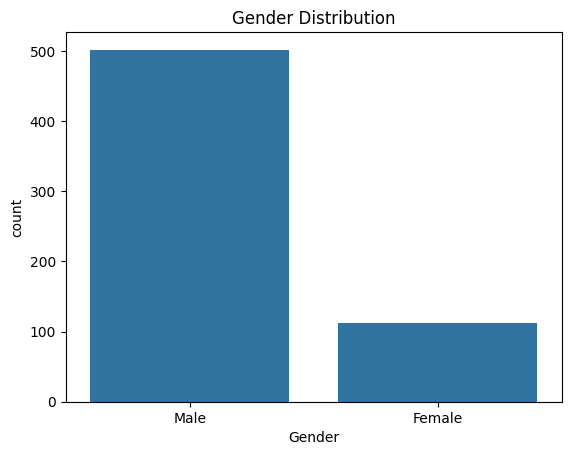

In [39]:
# 2 Gender Distribution

sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")

plt.show()

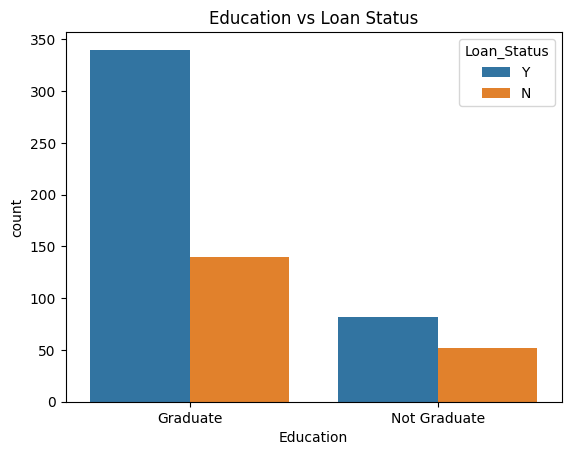

In [40]:
# 3 Education vs Loan Status
sns.countplot(x='Education', hue='Loan_Status', data=df)

plt.title("Education vs Loan Status")

plt.show()

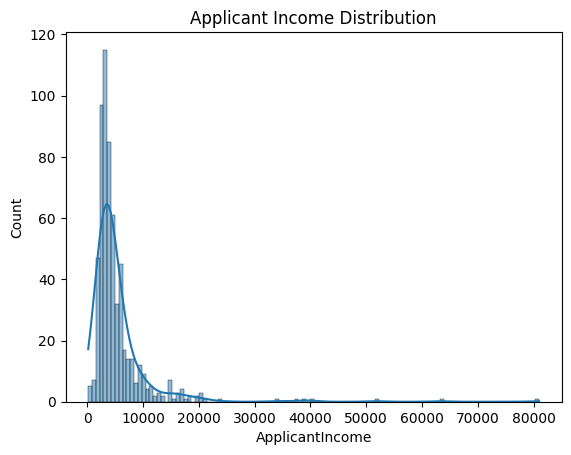

In [41]:
# 4 Income Distribution
sns.histplot(df['ApplicantIncome'], kde=True)

plt.title("Applicant Income Distribution")

plt.show()


In [44]:
# Data Encoding
le = LabelEncoder()

In [45]:
cols = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for col in cols:
    df[col] = le.fit_transform(df[col])

In [46]:
df['Dependents'] = df['Dependents'].replace('3+', 3)

df['Dependents'] = df['Dependents'].astype(int)

In [47]:
# Feature Selection
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)

In [48]:
y = df['Loan_Status']

In [49]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [50]:
# Logistic Regression Model
lr = LogisticRegression()

lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [51]:
# Prediction
y_pred_lr = lr.predict(X_test)

In [52]:
# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)


Logistic Regression Accuracy: 0.7886178861788617


In [53]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[18 25]
 [ 1 79]]


In [54]:
# Classification Report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [55]:
# Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [56]:
# Decision Tree Accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.6991869918699187


In [57]:
# Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [58]:
# Random Forest Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.7642276422764228


In [59]:
# Model Comparison
models = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ]
})

print(models)

                 Model  Accuracy
0  Logistic Regression  0.788618
1        Decision Tree  0.699187
2        Random Forest  0.764228


In [60]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

              Feature  Importance
9      Credit_History    0.262729
5     ApplicantIncome    0.197369
7          LoanAmount    0.191891
6   CoapplicantIncome    0.113623
8    Loan_Amount_Term    0.050583
10      Property_Area    0.049363
2          Dependents    0.047505
1             Married    0.023255
3           Education    0.022147
0              Gender    0.021512
4       Self_Employed    0.020023


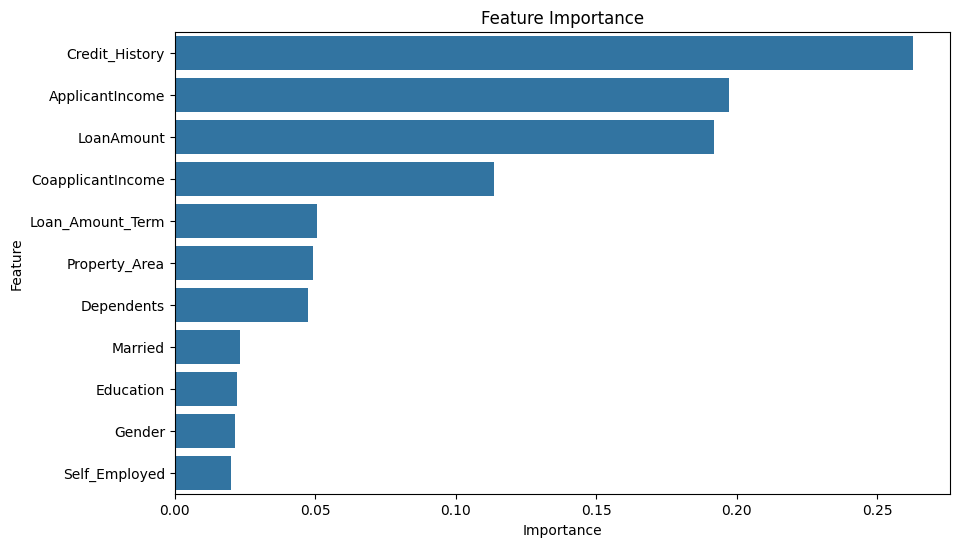

In [61]:
# Feature Importance Graph
plt.figure(figsize=(10,6))

sns.barplot(
    x=importance['Importance'],
    y=importance['Feature']
)

plt.title("Feature Importance")

plt.show()

In [62]:
# Final Prediction System
sample = X_test.iloc[0:1]

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Approved


In [63]:
# Random Forest Tuning
from sklearn.model_selection import GridSearchCV

In [64]:
# GridSearchCV

params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

In [65]:
grid = GridSearchCV(
    RandomForestClassifier(),
    params,
    cv=5
)

In [66]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10], 'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]})

In [67]:
print(grid.best_params_)

{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}


In [68]:
from sklearn.model_selection import cross_val_score

In [69]:
# cv
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

In [70]:
print(scores)
print(scores.mean())

[0.78861789 0.74796748 0.77235772 0.82926829 0.80327869]
0.7882980141276823


In [71]:
from xgboost import XGBClassifier

In [72]:
# Train Model
xgb = XGBClassifier()

In [73]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [74]:
y_pred_xgb = xgb.predict(X_test)

In [75]:
# Accuracy
accuracy_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)

print(accuracy_xgb)

0.7317073170731707


In [82]:
import pickle

In [83]:

pickle.dump(
    xgb,
    open('loan_model.pkl', 'wb')
)

In [84]:
model = pickle.load(
    open('loan_model.pkl', 'rb')
)